In [2]:
# link to dataset: https://www.kaggle.com/datasets/abdullahmeo/air-jordan-sneaker-market-and-resale-data2023-2026


Load in Dataset

In [3]:
import pandas as pd
data = pd.read_csv('jordan_market_dataset_2026.csv')

In [4]:
# as you can see there are no missing values in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     5000 non-null   object 
 1   Sale_Date          5000 non-null   object 
 2   Shoe_Model         5000 non-null   object 
 3   Colorway           5000 non-null   object 
 4   Condition          5000 non-null   object 
 5   Retail_Price_USD   5000 non-null   int64  
 6   Resale_Price_USD   5000 non-null   float64
 7   Sales_Channel      5000 non-null   object 
 8   Days_in_Inventory  5000 non-null   int64  
 9   Profit_Margin_USD  5000 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 390.8+ KB


In [5]:
# no duplicates either
data.duplicated().sum()

np.int64(0)

Introducing some errors

In [6]:
import random
random_nums = random.sample(range(0,data.shape[0]), 20)



Introducing NAs

In [7]:
import numpy as np
for num in random_nums:
  rand = random.randint(0,data.shape[1] -1)
  data.iloc[num,rand] = np.nan

Introducing duplicate transcation IDs

In [8]:
random_nums = random.sample(range(0,data.shape[0]), 20)


In [9]:
# now we have 20 random rows with transaction id the same
for num in random_nums:
  data = pd.concat([data, data.iloc[[num]]], ignore_index=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     5020 non-null   object 
 1   Sale_Date          5017 non-null   object 
 2   Shoe_Model         5019 non-null   object 
 3   Colorway           5016 non-null   object 
 4   Condition          5020 non-null   object 
 5   Retail_Price_USD   5017 non-null   float64
 6   Resale_Price_USD   5019 non-null   float64
 7   Sales_Channel      5018 non-null   object 
 8   Days_in_Inventory  5016 non-null   float64
 9   Profit_Margin_USD  5017 non-null   float64
dtypes: float64(4), object(6)
memory usage: 392.3+ KB


Start Preprocessing

Remove duplicates from the dataset.

In [11]:
duplicates = data.duplicated()
data[duplicates] # we will be dropping all these rows

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
5000,TRX-100171,2023-03-20,Air Jordan 4 Retro,Chicago,Deadstock (Brand New),217.0,538.58,Stadium Goods,52.0,321.58
5001,TRX-104566,2025-01-25,Air Jordan 11 Retro,Concord,VNDS (Very Near Deadstock),230.0,317.30,GOAT,11.0,87.30
5002,TRX-104885,2023-06-07,Air Jordan 11 Retro,Concord,VNDS (Very Near Deadstock),227.0,233.35,kick hub 2026,8.0,6.35
5003,TRX-104687,2025-09-07,Air Jordan 4 Retro,Pine Green,Used,216.0,122.80,Walk-in Retail,5.0,-93.20
5004,TRX-101594,2023-12-18,Air Jordan 3 Retro,Lost & Found,Used,205.0,112.95,Stadium Goods,42.0,-92.05
5005,TRX-103743,2024-10-16,Air Jordan 1 High,Sail,Used,179.0,144.19,Stadium Goods,23.0,-34.81
5006,TRX-100664,2023-02-12,Air Jordan 3 Retro,Concord,VNDS (Very Near Deadstock),206.0,271.79,GOAT,1.0,65.79
5007,TRX-104807,2025-05-04,Air Jordan 11 Retro,Bred,VNDS (Very Near Deadstock),229.0,342.06,kick hub 2026,43.0,113.06
5008,TRX-100723,2023-04-21,Air Jordan 1 High,Military Blue,VNDS (Very Near Deadstock),NaN,231.29,GOAT,8.0,58.29
5009,TRX-103646,2025-06-19,Air Jordan 1 High,Military Blue,VNDS (Very Near Deadstock),190.0,246.30,kick hub 2026,17.0,56.30


In [12]:
data.drop_duplicates(inplace= True)

Handle missing values

---



In [13]:
data[data.isna().any(axis =1)]

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
26,TRX-100027,2024-03-13,Air Jordan 1 High,Lost & Found,Deadstock (Brand New),188.0,612.42,NaN,10.0,424.42
384,TRX-100385,NaN,Air Jordan 4 Retro,Chicago,Deadstock (Brand New),218.0,639.44,Walk-in Retail,17.0,421.44
631,TRX-100632,2023-03-30,Air Jordan 3 Retro,Sail,Deadstock (Brand New),NaN,640.40,StockX,6.0,434.40
722,TRX-100723,2023-04-21,Air Jordan 1 High,Military Blue,VNDS (Very Near Deadstock),NaN,231.29,GOAT,8.0,58.29
750,TRX-100751,2024-09-17,Air Jordan 4 Retro,Military Blue,Deadstock (Brand New),213.0,730.88,GOAT,7.0,NaN
791,TRX-100792,2023-02-20,Air Jordan 4 Retro,Black Cat,Used,221.0,182.61,kick hub 2026,NaN,-38.39
1079,TRX-101080,2023-01-26,NaN,Mocha,Deadstock (Brand New),217.0,710.01,Stadium Goods,56.0,493.01
1238,TRX-101239,2025-08-19,Air Jordan 4 Retro,Pine Green,Used,223.0,134.44,NaN,10.0,-88.56
1267,TRX-101268,2024-03-22,Air Jordan 1 High,NaN,Deadstock (Brand New),186.0,317.10,StockX,2.0,131.10
1915,TRX-101916,NaN,Air Jordan 1 Low,Concord,Used,114.0,98.22,GOAT,4.0,-15.78


In [14]:
data = data.dropna(how = 'any',axis = 0)

Standardize categorical values (e.g., "M", "Male", "male" → "Male").


In [15]:
# we are going to convert these into more readable names
data['Condition'].value_counts()

,count
Condition,
Deadstock (Brand New),1670
VNDS (Very Near Deadstock),1661
Used,1649


In [16]:
data[data['Condition'] == 'Deadstock (Brand New)']['Condition'] =  'New'
data[data['Condition'] == 'VNDS (Very Near Deadstock)']['Condition']  = 'Almost New'

/tmp/ipykernel_4570/1112040068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data['Condition'] == 'Deadstock (Brand New)']['Condition'] =  'New'
/tmp/ipykernel_4570/1112040068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data['Condition'] == 'VNDS (Very Near Deadstock)']['Condition']  = 'Almost New'


In [17]:
data.head(10)

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
0,TRX-100001,2024-10-23,Air Jordan 11 Retro,Sail,Used,225.0,194.67,GOAT,13.0,-30.33
1,TRX-100002,2023-10-23,Air Jordan 1 High,Mocha,Deadstock (Brand New),185.0,230.46,StockX,10.0,45.46
2,TRX-100003,2023-11-13,Air Jordan 4 Retro,Concord,Deadstock (Brand New),212.0,270.37,kick hub 2026,33.0,58.37
3,TRX-100004,2024-02-01,Air Jordan 4 Retro,Mocha,Used,223.0,180.43,Stadium Goods,60.0,-42.57
4,TRX-100005,2023-05-29,Air Jordan 1 Low,Mocha,Used,137.0,117.43,kick hub 2026,30.0,-19.57
5,TRX-100006,2024-05-04,Air Jordan 1 Low,Concord,VNDS (Very Near Deadstock),131.0,141.32,kick hub 2026,34.0,10.32
6,TRX-100007,2025-07-21,Air Jordan 3 Retro,Sail,Used,204.0,138.28,Walk-in Retail,38.0,-65.72
7,TRX-100008,2023-05-13,Air Jordan 1 Low,Black Cat,Deadstock (Brand New),129.0,295.90,kick hub 2026,31.0,166.90
8,TRX-100009,2023-05-30,Air Jordan 3 Retro,Bred,VNDS (Very Near Deadstock),205.0,248.04,StockX,1.0,43.04
9,TRX-100010,2023-10-16,Air Jordan 4 Retro,Bred,Used,219.0,170.96,Walk-in Retail,44.0,-48.04


Remove Outliers. By removing any row with profit margin greater than 500





In [18]:
outliers = data[data['Profit_Margin_USD'] >= 500].index

In [19]:
data.iloc[outliers]

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
54,TRX-100055,2025-06-20,Air Jordan 3 Retro,Bred,VNDS (Very Near Deadstock),202.0,211.51,StockX,8.0,9.51
74,TRX-100075,2024-10-08,Air Jordan 1 High,Bred,VNDS (Very Near Deadstock),187.0,225.83,Stadium Goods,21.0,38.83
120,TRX-100121,2025-03-30,Air Jordan 11 Retro,Sail,Deadstock (Brand New),225.0,431.80,GOAT,8.0,206.80
139,TRX-100140,2023-05-21,Air Jordan 1 High,Concord,VNDS (Very Near Deadstock),172.0,242.38,StockX,2.0,70.38
252,TRX-100253,2025-05-27,Air Jordan 4 Retro,Military Blue,Deadstock (Brand New),224.0,773.88,StockX,13.0,549.88
...,...,...,...,...,...,...,...,...,...,...
4776,TRX-104777,2024-12-20,Air Jordan 3 Retro,Concord,Used,208.0,117.18,GOAT,4.0,-90.82
4847,TRX-104848,2025-08-31,Air Jordan 11 Retro,Pine Green,VNDS (Very Near Deadstock),226.0,307.63,GOAT,10.0,81.63
4878,TRX-104879,2024-01-24,Air Jordan 3 Retro,Sail,VNDS (Very Near Deadstock),206.0,241.41,StockX,8.0,35.41
4901,TRX-104902,2025-08-10,Air Jordan 3 Retro,Bred,Deadstock (Brand New),202.0,369.00,kick hub 2026,54.0,167.00


Uniform case standardization for text (decide and apply lower/upper consistently; trim whitespace).


In [20]:
# we are going to make all words in Sales_Channel to lowercase and strip whitespace
data['Sales_Channel'] =data['Sales_Channel'].str.lower()
data['Sales_Channel'] = data['Sales_Channel'].str.strip()


In [21]:
data = data.drop(index = outliers)

In [22]:
data.to_csv('diy_dataset.csv')

Initially in the beginning there was no errors in the dataset regarding NA's or duplicates so I had to artificially introduce them. After we introduced them we dropped any rows that was a duplicate or had a NA in any column. On the other hand there was outliers in the dataset in terms of profit margin. We decided to remove any rows with a profit margin greater than $500. Additionally in terms of text preprocessing the data set had ambigous names for condition of shoe, so we had to replace the values to more interpretable ones. Furthermore there was a mix of case convention in the sales_channel column, so we just made it all lower case

Part Analysis

Top-N within each group

In [23]:
from pandas import DataFrame
temp = data.groupby(['Shoe_Model','Colorway'])['Resale_Price_USD'].mean()
temp = DataFrame(temp)
temp.sort_values(['Shoe_Model', 'Resale_Price_USD'], ascending=[True, False]).groupby('Shoe_Model').head(3)

Resale_Price_USD
Shoe_Model          Colorway                       
Air Jordan 1 High   Concord              287.186224
                    Chicago              273.813617
                    Mocha                271.966813
Air Jordan 1 Low    Sail                 191.808070
                    Concord              180.437431
                    Military Blue        179.220909
Air Jordan 11 Retro Military Blue        333.015841
                    Mocha                323.722476
                    Lost & Found         310.839189
Air Jordan 3 Retro  Pine Green           294.360167
                    Military Blue        290.850000
                    Chicago              290.381698
Air Jordan 4 Retro  Military Blue        322.506132
                    Lost & Found         310.947966
                    Pine Green           308.132095

In [24]:
data['Retail Price Bins']= pd.cut(data['Retail_Price_USD'],bins = 5,labels = ['Cheap','Less Expensive','Medium Price','More Expensive','Really Expensive'] )
data.groupby('Retail Price Bins')['Profit_Margin_USD'].mean()


/tmp/ipykernel_4570/3099106613.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Retail Price Bins')['Profit_Margin_USD'].mean()


,Profit_Margin_USD
Retail Price Bins,
Cheap,48.817738
Less Expensive,57.431923
Medium Price,76.925173
More Expensive,80.043626
Really Expensive,80.297579


Percentage Distribution

In [25]:
total_profit = data['Profit_Margin_USD'].sum()

In [26]:
data.groupby('Sales_Channel')['Profit_Margin_USD'].sum()/total_profit

,Profit_Margin_USD
Sales_Channel,
goat,0.208053
kick hub 2026,0.190574
stadium goods,0.201336
stockx,0.181031
walk-in retail,0.219006


Change over time

In [27]:
# using prior knowledge of datetime object in python
data['Month'] = data['Sale_Date'].str[5:7]
data.groupby('Month')['Resale_Price_USD'].mean()


,Resale_Price_USD
Month,
01,264.031857
02,270.078947
03,267.917709
04,259.993792
05,271.339630
06,262.262976
07,266.864990
08,262.325248
09,259.113255


Visualization

Scatter plot

Text(0, 0.5, 'Profit USD')

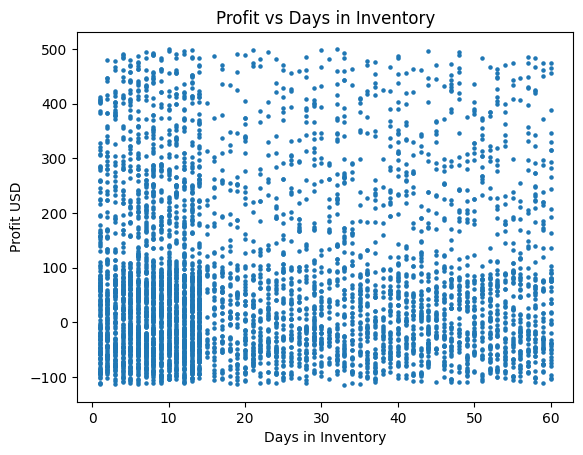

In [28]:
import matplotlib.pyplot as plt

plt.scatter(data['Days_in_Inventory'],data['Profit_Margin_USD'],s = 5)
plt.title("Profit vs Days in Inventory")
plt.xlabel("Days in Inventory")
plt.ylabel("Profit USD")

This chart tells us here that there is almost no correlation between the amount of times our shoe stays in inventory and the profit margin we sell it for. This could mean that even for items that don't sell as fast we aren't letting lead us to sell for less profit.

Pie Graph

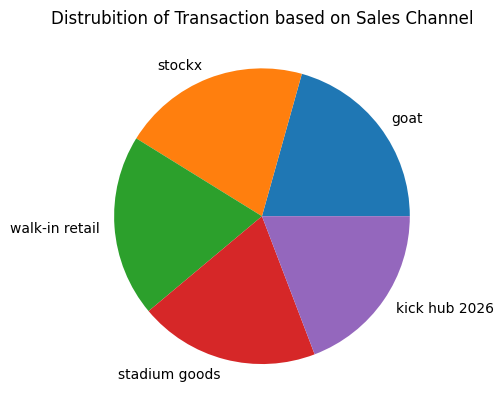

In [29]:
counts = data['Sales_Channel'].value_counts()

plt.pie(counts.values, labels=counts.index)
plt.title("Distrubition of Transaction based on Sales Channel")
plt.show()


As we can see in this dataset there is an even distribution of sales channels. Every channel has about the same number of transactions

Histogram

Text(0, 0.5, 'Frequency')

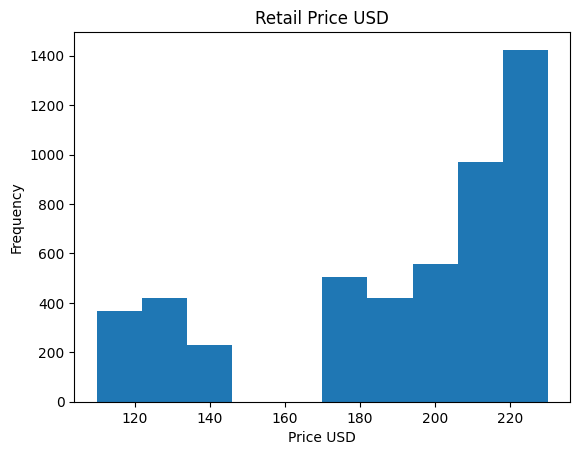

In [30]:
plt.hist(data['Retail_Price_USD'])
plt.title("Retail Price USD")
plt.xlabel("Price USD")
plt.ylabel("Frequency")

As we can see our data for retail price is left skewed. There is 2 clear groups of shoes retail price one group below \$150 and one group above \$170

Heatmap

Text(0.5, 1.0, 'Average Days in Inventory')

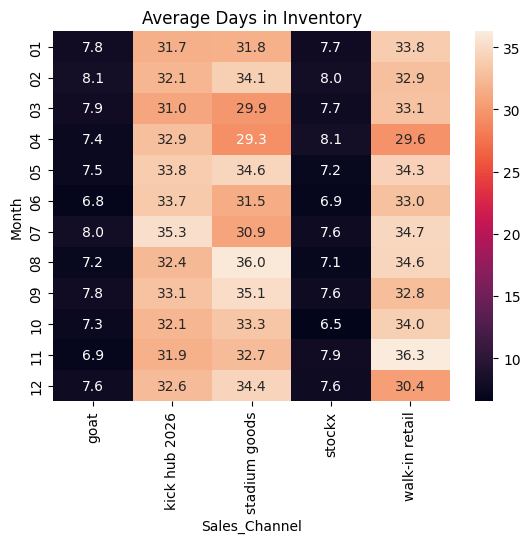

In [31]:
import seaborn as sns
heatmap = data.pivot_table(index='Month', columns='Sales_Channel', values='Days_in_Inventory', aggfunc='mean')
sns.heatmap(heatmap, annot=True, fmt='.1f')
plt.title('Average Days in Inventory')


As you can see it is clear that shoes on goat and stockx tend to sell much much faster.

Box plot


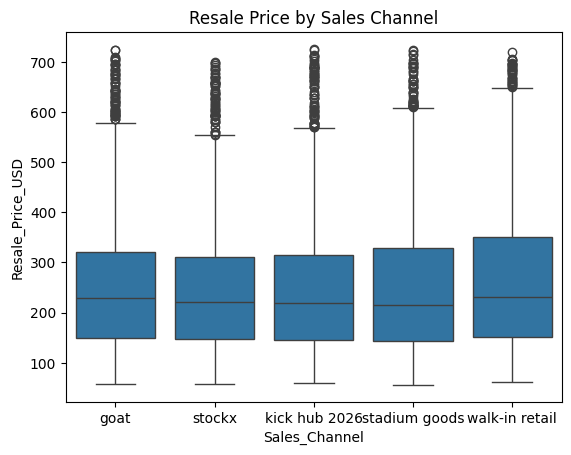

In [32]:
sns.boxplot(data=data, x='Sales_Channel', y='Resale_Price_USD')
plt.title("Resale Price by Sales Channel")
plt.show()

As you can see there is quite a lot of outliers in terms of resale price.Other wise all sales channel seem to have a similar distribution of resale price, none much differnet than the other.